In [24]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import DeconV as dv

In [25]:
true_proportions = pd.read_table("../data/xin/proportions.txt", index_col=0)
true_proportions = true_proportions.sort_index(axis="columns").sort_index(axis="rows")
true_proportions.index.name = None
true_proportions

,alpha,beta,delta,gamma
Non T2D 1,0.716216,0.175676,0.067568,0.040541
Non T2D 10,0.418605,0.534884,0.046512,0.000000
Non T2D 11,0.796610,0.169492,0.016949,0.016949
Non T2D 12,0.626866,0.358209,0.014925,0.000000
Non T2D 2,0.166667,0.541667,0.083333,0.208333
Non T2D 3,0.642857,0.238095,0.071429,0.047619
Non T2D 4,0.518519,0.370370,0.000000,0.111111
Non T2D 5,0.442308,0.423077,0.096154,0.038462
Non T2D 6,0.750000,0.145833,0.083333,0.020833
Non T2D 7,0.296296,0.555556,0.000000,0.148148


In [26]:
cs_proportions = pd.read_table("3rd-party/cibersort/xin/cibersort_proportions.txt", index_col=0)
cs_proportions = cs_proportions.iloc[:, :-3]
cs_proportions = cs_proportions.sort_index(axis="columns").sort_index(axis="rows")
cs_proportions.index.name = None
cs_proportions

,alpha,beta,delta,gamma
Non T2D 1,0.885638,0.012844,0.078042,0.023477
Non T2D 10,0.882146,0.053763,0.064091,0.000000
Non T2D 11,0.952714,0.015582,0.018971,0.012733
Non T2D 12,0.940983,0.052172,0.006844,0.000000
Non T2D 2,0.471585,0.097158,0.142065,0.289193
Non T2D 3,0.909359,0.013918,0.050755,0.025968
Non T2D 4,0.748159,0.048276,0.000000,0.203565
Non T2D 5,0.794382,0.036628,0.123559,0.045432
Non T2D 6,0.944384,0.002726,0.052890,0.000000
Non T2D 7,0.698413,0.059493,0.000000,0.242094


In [27]:
deconv_proportions = pd.read_csv("out/xin/gamma/proportions_separate_bd.tsv", sep="\t", index_col=0)
deconv_proportions = deconv_proportions.sort_index(axis="columns").sort_index(axis="rows")
deconv_proportions

,alpha,beta,delta,gamma
Non T2D 1,0.508875,0.384286,0.034605,0.072233
Non T2D 10,0.554365,0.402802,0.042820,0.000013
Non T2D 11,0.671995,0.258385,0.010545,0.059076
Non T2D 12,0.594978,0.398239,0.006776,0.000006
Non T2D 2,0.163490,0.600207,0.025993,0.210310
Non T2D 3,0.739277,0.163760,0.047965,0.048998
Non T2D 4,0.509571,0.306085,0.000005,0.184340
Non T2D 5,0.533381,0.333964,0.093135,0.039520
Non T2D 6,0.850356,0.092353,0.057277,0.000013
Non T2D 7,0.348887,0.462488,0.000003,0.188622


In [28]:
music_proportions = pd.read_csv("3rd-party/music/xin/music_proportions.csv", index_col=0)
music_proportions = music_proportions.sort_index(axis="columns").sort_index(axis="rows")
music_proportions.index.name = None
music_proportions

,alpha,beta,delta,gamma
Non T2D 1,0.421269,0.536488,0.033483,0.008760
Non T2D 10,0.514780,0.444490,0.040730,0.000000
Non T2D 11,0.740086,0.242773,0.010546,0.006595
Non T2D 12,0.638644,0.356975,0.004381,0.000000
Non T2D 2,0.052573,0.893437,0.017240,0.036750
Non T2D 3,0.818588,0.109515,0.049301,0.022596
Non T2D 4,0.484339,0.415445,0.000000,0.100216
Non T2D 5,0.377824,0.531229,0.068855,0.022091
Non T2D 6,0.905897,0.026713,0.067390,0.000000
Non T2D 7,0.305537,0.590466,0.000000,0.103998


In [29]:
scaden_proportions = pd.read_csv("3rd-party/scaden/xin/scaden_predictions.txt", sep="\t", index_col=0)
scaden_proportions = scaden_proportions.sort_index(axis="columns").sort_index(axis="rows")
scaden_proportions

,alpha,beta,delta,gamma
Non T2D 1,0.605766,0.269062,0.037922,0.087249
Non T2D 10,0.380902,0.463801,0.068493,0.086804
Non T2D 11,0.514097,0.296886,0.042230,0.146787
Non T2D 12,0.523361,0.386476,0.026789,0.063374
Non T2D 2,0.179598,0.480330,0.078972,0.261100
Non T2D 3,0.468044,0.330252,0.084200,0.117503
Non T2D 4,0.383280,0.394448,0.033489,0.188783
Non T2D 5,0.388165,0.464595,0.087220,0.060020
Non T2D 6,0.547889,0.259040,0.079516,0.113554
Non T2D 7,0.293945,0.513243,0.025798,0.167013


In [30]:
melt = true_proportions.reset_index().melt(id_vars="index")
melt.rename(columns={"index": "sample", "value": "true", "variable":"cell_type"}, inplace=True)
melt["deconv"] = deconv_proportions.reset_index().melt(id_vars="index")["value"]
melt["scaden"] = scaden_proportions.reset_index().melt(id_vars="index")["value"]
melt["music"] = music_proportions.reset_index().melt(id_vars="index")["value"]
melt["cs"] = cs_proportions.reset_index().melt(id_vars="index")["value"]
melt

,sample,cell_type,true,deconv,scaden,music,cs
0,Non T2D 1,alpha,0.716216,0.508875,0.605766,0.421269,0.885638
1,Non T2D 10,alpha,0.418605,0.554365,0.380902,0.514780,0.882146
2,Non T2D 11,alpha,0.796610,0.671995,0.514097,0.740086,0.952714
3,Non T2D 12,alpha,0.626866,0.594978,0.523361,0.638644,0.940983
4,Non T2D 2,alpha,0.166667,0.163490,0.179598,0.052573,0.471585
...,...,...,...,...,...,...,...
67,T2D 2,gamma,0.120482,0.099753,0.186754,0.026645,0.042201
68,T2D 3,gamma,0.050000,0.115642,0.178797,0.030415,0.043686
69,T2D 4,gamma,0.007143,0.009878,0.060863,0.002148,0.002506
70,T2D 5,gamma,0.006061,0.001488,0.081705,0.000000,0.000000


In [31]:
def ccc(est, true):
    p = np.corrcoef(est, true)[0,1]
    mu_est = np.mean(est)
    mu_true = np.mean(true)
    s_est = np.std(est)
    s_true = np.std(true)

    return (2.0 * p * s_est * s_true) / (s_est**2 + s_true**2 + (mu_est - mu_true)**2)

p_deconv = np.corrcoef(melt["true"], melt["deconv"])[0,1]
p_scaden = np.corrcoef(melt["true"], melt["scaden"])[0,1]
p_music = np.corrcoef(melt["true"], melt["music"])[0,1]
p_cs = np.corrcoef(melt["true"], melt["cs"])[0,1]

ccc_deconv = ccc(melt["true"], melt["deconv"])
ccc_scaden = ccc(melt["true"], melt["scaden"])
ccc_music = ccc(melt["true"], melt["music"])
ccc_cs = ccc(melt["true"], melt["cs"])

print("DeconV: Pearson correlation coefficient: {:.3f}, CCC: {:.3f}".format(p_deconv, ccc_deconv))
print("SCADEN: Pearson correlation coefficient: {:.3f}, CCC: {:.3f}".format(p_scaden, ccc_scaden))
print("MuSiC: Pearson correlation coefficient: {:.3f}, CCC: {:.3f}".format(p_music, ccc_music))
print("CIBERSORT: Pearson correlation coefficient: {:.3f}, CCC: {:.3f}".format(p_cs, ccc_cs))

DeconV: Pearson correlation coefficient: 0.968, CCC: 0.968
SCADEN: Pearson correlation coefficient: 0.963, CCC: 0.926
MuSiC: Pearson correlation coefficient: 0.938, CCC: 0.929
CIBERSORT: Pearson correlation coefficient: 0.781, CCC: 0.731


In [32]:
df = true_proportions.reset_index().melt(id_vars="index")
df.rename(columns={"index": "sample", "value": "proportion", "variable":"cell_type"}, inplace=True)
df["type"] = "true"
df["error"] = None

melt["deconv_error"] = abs(melt["deconv"] - melt["true"])
melt["deconv_squared_error"] = melt["deconv_error"]**2
melt["cs_error"] = abs(melt["cs"] - melt["true"])
melt["cs_squared_error"] = melt["cs_error"]**2
melt["scaden_error"] = abs(melt["scaden"] - melt["true"])
melt["scaden_squared_error"] = melt["scaden_error"]**2
melt["music_error"] = abs(melt["music"] - melt["true"])
melt["music_squared_error"] = melt["music_error"]**2

temp = melt[["sample", "cell_type", "deconv", "deconv_error", "deconv_squared_error"]].rename(
    columns={"deconv": "proportion", "deconv_error": "error", "deconv_squared_error": "squared_error"}
)
temp["type"] = "deconv"
df = pd.concat([df, temp])

temp = melt[["sample", "cell_type", "scaden", "scaden_error", "scaden_squared_error"]].rename(
    columns={"scaden": "proportion", "scaden_error": "error", "scaden_squared_error": "squared_error"}
)
temp["type"] = "scaden"
df = pd.concat([df, temp])

temp = melt[["sample", "cell_type", "music", "music_error", "music_squared_error"]].rename(
    columns={"music": "proportion", "music_error": "error", "music_squared_error": "squared_error"}
)
temp["type"] = "music"
df = pd.concat([df, temp])

temp = melt[["sample", "cell_type", "cs", "cs_error", "cs_squared_error"]].rename(
    columns={"cs": "proportion", "cs_error": "error", "cs_squared_error": "squared_error"}
)
temp["type"] = "cs"
df = pd.concat([df, temp])

df

,sample,cell_type,proportion,type,error,squared_error
0,Non T2D 1,alpha,0.716216,true,NaN,NaN
1,Non T2D 10,alpha,0.418605,true,NaN,NaN
2,Non T2D 11,alpha,0.796610,true,NaN,NaN
3,Non T2D 12,alpha,0.626866,true,NaN,NaN
4,Non T2D 2,alpha,0.166667,true,NaN,NaN
...,...,...,...,...,...,...
67,T2D 2,gamma,0.042201,cs,0.078281,0.006128
68,T2D 3,gamma,0.043686,cs,0.006314,0.000040
69,T2D 4,gamma,0.002506,cs,0.004637,0.000022
70,T2D 5,gamma,0.000000,cs,0.006061,0.000037


/home/lutrarutra/.pyenv/versions/3.10.9/envs/lst/lib/python3.10/site-packages/seaborn/categorical.py:166: FutureWarning: Setting a gradient palette using color= is deprecated and will be removed in version 0.13. Set `palette='dark:.25'` for same effect.
  warnings.warn(msg, FutureWarning)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


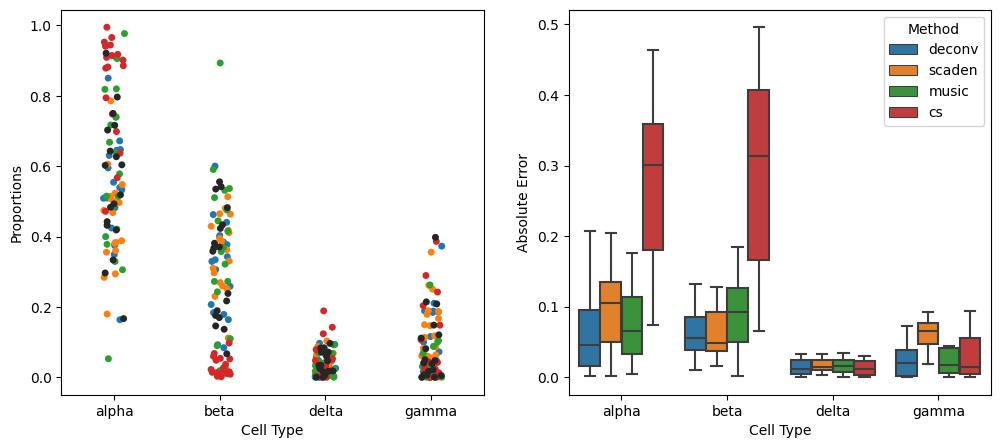

In [33]:
f, ax = plt.subplots(1,2, figsize=(12,5), dpi=100)

sns.stripplot(data=df[df["type"] != "true"], x="cell_type", y="proportion", hue="type", ax=ax[0])
sns.stripplot(data=df[df["type"] == "true"], x="cell_type", y="proportion", hue="type", ax=ax[0], color=".25")
plt.legend(title="Method")
sns.boxplot(data=df[df["type"] != "true"], x="cell_type", y="error", hue="type", ax=ax[1], showfliers=False)

ax[0].set_ylabel("Proportions")
ax[1].set_ylabel("Absolute Error")
ax[0].set_xlabel("Cell Type")
ax[1].set_xlabel("Cell Type")
ax[0].get_legend().remove()
ax[1].get_legend().set_title("Method")

plt.savefig("comparison/xin/per_celltype.pdf", bbox_inches="tight")

plt.show()

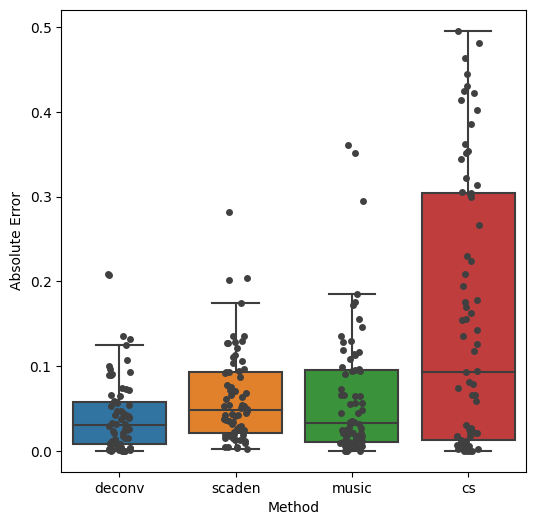

In [34]:
f, ax = plt.subplots(1, 1, figsize=(6,6), dpi=100)
sns.boxplot(data=df[df["type"] != "true"], y="error", x="type", showfliers=False, ax=ax)
sns.stripplot(data=df[df["type"] != "true"], x="type", y="error", ax=ax, color=".25")
ax.set_ylabel("Absolute Error")
ax.set_xlabel("Method")
plt.savefig("comparison/xin/box_abs_error.pdf", bbox_inches="tight")
plt.show()

In [35]:
df.groupby("type")[["error", "squared_error"]].mean()

,error,squared_error
type,,
cs,0.155399,0.049049
deconv,0.042086,0.003761
music,0.063574,0.009764
scaden,0.062844,0.006857
true,NaN,NaN


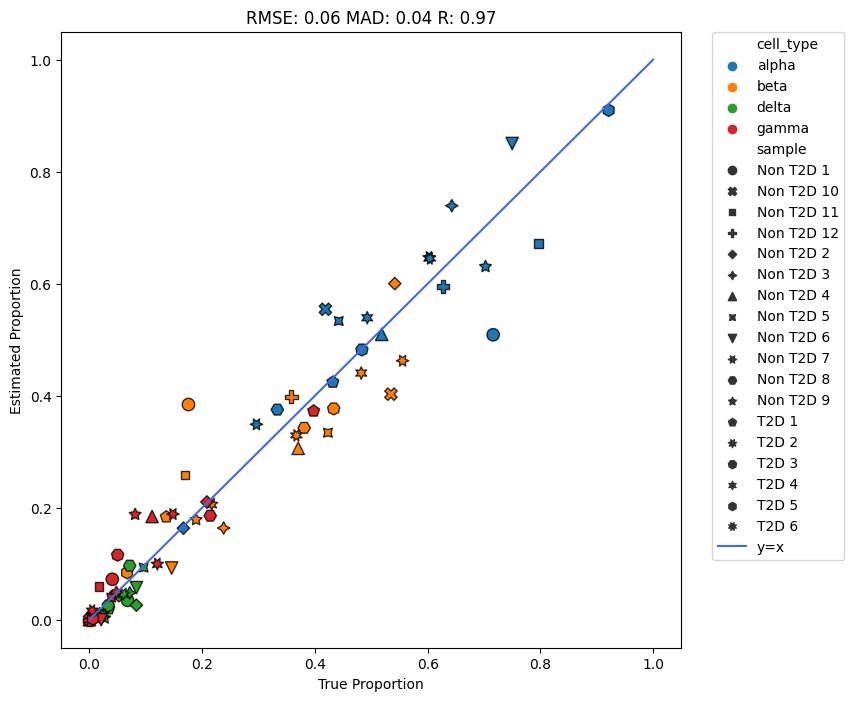

(0.06132400374360676, 0.04208649686930558, 0.9678561248013836)

In [36]:
dv.pl.xypredictions(melt, x="true", y="deconv")